In [1]:
import os
os.chdir('../')
os.getcwd()

'/home/minh_khai/salinity/ai-agent-learning/quick-ai-agent-test'

In [2]:
from typing import TypedDict

class JokeState(TypedDict):
    topic:  str
    joke:   str
    expl:   str

In [3]:
from dotenv import load_dotenv
load_dotenv()
from langchain_anthropic import ChatAnthropic

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [4]:
def make_joke(state: JokeState) -> JokeState:
    prompt = f'generate a joke on the topic {state["topic"]}'
    joke   = llm.invoke(prompt).content
    
    return {'joke': joke}

def try_explain(state: JokeState) -> JokeState:
    prompt = f'write an explanation for the joke - {state["joke"]}'
    expl   = llm.invoke(prompt).content
    return {'expl': expl}

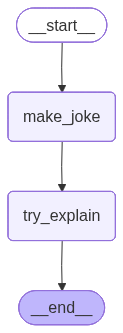

In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

graph = StateGraph(JokeState)

graph.add_node('make_joke', make_joke)
graph.add_node('try_explain', try_explain)

graph.add_edge(START, 'make_joke')
graph.add_edge('make_joke', 'try_explain')
graph.add_edge('try_explain', END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [7]:
config = {
    "configurable": {"thread_id": "1"}
}

result = workflow.invoke({"topic": "cats"}, config=config)
result

{'topic': 'cats',
 'joke': "# 🐱 Cat Joke\n\nWhy don't cats play poker in the jungle?\n\nBecause there are too many **cheetahs**! 🐆\n\n---\n\n*Bonus joke:* What do cats eat for breakfast? \n**Mice Krispies!** 🥣",
 'expl': '# Joke Explanation\n\n## Main Joke: "Why don\'t cats play poker in the jungle?"\n\nThis is a **pun-based joke** that plays on a homophone (words that sound the same but have different meanings):\n\n- **"Cheetahs"** (the wild cat animal) sounds identical to **"cheaters"** (people who play unfairly)\n- The joke sets up an expectation about the jungle being dangerous for cats\n- The punchline subverts this by using the sound-alike word to suggest that cheetahs would *cheat* at poker, making it an unfair game\n\n**Why it\'s funny:** It combines literal meaning (actual cheetahs in the jungle) with the figurative meaning (cheaters at a card game), creating an unexpected twist.\n\n---\n\n## Bonus Joke: "What do cats eat for breakfast?"\n\nThis is also a **pun**, but it works

## CHECK STATES

In [10]:
for state in workflow.get_state_history(config):
    print("NEXT:", state.next)
    print("KEYS:", list(state.values.keys()))
    print("---")

NEXT: ()
KEYS: ['topic', 'joke', 'expl']
---
NEXT: ('try_explain',)
KEYS: ['topic', 'joke', 'expl']
---
NEXT: ('make_joke',)
KEYS: ['topic', 'joke', 'expl']
---
NEXT: ('__start__',)
KEYS: ['topic', 'joke', 'expl']
---
NEXT: ()
KEYS: ['topic', 'joke', 'expl']
---
NEXT: ('try_explain',)
KEYS: ['topic', 'joke']
---
NEXT: ('make_joke',)
KEYS: ['topic']
---
NEXT: ('__start__',)
KEYS: []
---


In [12]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'cats', 'joke': "# 🐱 Cat Joke\n\nWhy don't cats play poker in the jungle?\n\nBecause there are too many **cheetahs**! 🐆\n\n---\n\n*Bonus joke:* What do cats eat for breakfast? \n**Mice Krispies!** 🥣", 'expl': '# Joke Explanation\n\n## Main Joke: "Why don\'t cats play poker in the jungle?"\n\nThis is a **pun-based joke** that plays on a homophone (words that sound the same but have different meanings):\n\n- **"Cheetahs"** (the wild cat animal) sounds identical to **"cheaters"** (people who play unfairly)\n- The joke sets up an expectation about the jungle being dangerous for cats\n- The punchline subverts this by using the sound-alike word to suggest that cheetahs would *cheat* at poker, making it an unfair game\n\n**Why it\'s funny:** It combines literal meaning (actual cheetahs in the jungle) with the figurative meaning (cheaters at a card game), creating an unexpected twist.\n\n---\n\n## Bonus Joke: "What do cats eat for breakfast?"\n\nThis is also a **

In [13]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'cats', 'joke': "# 🐱 Cat Joke\n\nWhy don't cats play poker in the jungle?\n\nBecause there are too many **cheetahs**! 🐆\n\n---\n\n*Bonus joke:* What do cats eat for breakfast? \n**Mice Krispies!** 🥣", 'expl': '# Joke Explanation\n\n## Main Joke: "Why don\'t cats play poker in the jungle?"\n\nThis is a **pun-based joke** that plays on a homophone (words that sound the same but have different meanings):\n\n- **"Cheetahs"** (the wild cat animal) sounds identical to **"cheaters"** (people who play unfairly)\n- The joke sets up an expectation about the jungle being dangerous for cats\n- The punchline subverts this by using the sound-alike word to suggest that cheetahs would *cheat* at poker, making it an unfair game\n\n**Why it\'s funny:** It combines literal meaning (actual cheetahs in the jungle) with the figurative meaning (cheaters at a card game), creating an unexpected twist.\n\n---\n\n## Bonus Joke: "What do cats eat for breakfast?"\n\nThis is also a *

In [14]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'football'}, config=config2)

{'topic': 'football',
 'joke': "# Football Joke ⚽\n\nWhy did the football player go to the bank?\n\nHe wanted to get his quarterback!\n\n---\n\n*Or here's another one:*\n\nWhy don't football players ever go on vacation?\n\nBecause they'd lose their jobs if they left the field! 😄",
 'expl': '# Explanation of These Football Jokes ⚽\n\n## Joke #1: The Bank/Quarterback Pun\n\n**The Setup:** "Why did the football player go to the bank? He wanted to get his quarterback!"\n\n**How it Works:**\n- This is a **homophone pun** (words that sound the same but have different meanings)\n- "Quarter" + "back" sounds like "quarterback" (the position)\n- But it\'s being used literally as "quarter-back" — slang for getting your quarters back from the bank\n- The humor comes from the unexpected twist: you expect a football-related answer, but get a banking one instead\n\n**Why it\'s funny:** It plays on your assumptions about what "quarterback" means in a football context.\n\n---\n\n## Joke #2: The Vacatio

In [15]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'football', 'joke': "# Football Joke ⚽\n\nWhy did the football player go to the bank?\n\nHe wanted to get his quarterback!\n\n---\n\n*Or here's another one:*\n\nWhy don't football players ever go on vacation?\n\nBecause they'd lose their jobs if they left the field! 😄", 'expl': '# Explanation of These Football Jokes ⚽\n\n## Joke #1: The Bank/Quarterback Pun\n\n**The Setup:** "Why did the football player go to the bank? He wanted to get his quarterback!"\n\n**How it Works:**\n- This is a **homophone pun** (words that sound the same but have different meanings)\n- "Quarter" + "back" sounds like "quarterback" (the position)\n- But it\'s being used literally as "quarter-back" — slang for getting your quarters back from the bank\n- The humor comes from the unexpected twist: you expect a football-related answer, but get a banking one instead\n\n**Why it\'s funny:** It plays on your assumptions about what "quarterback" means in a football context.\n\n---\n\n## J

In [16]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'football', 'joke': "# Football Joke ⚽\n\nWhy did the football player go to the bank?\n\nHe wanted to get his quarterback!\n\n---\n\n*Or here's another one:*\n\nWhy don't football players ever go on vacation?\n\nBecause they'd lose their jobs if they left the field! 😄", 'expl': '# Explanation of These Football Jokes ⚽\n\n## Joke #1: The Bank/Quarterback Pun\n\n**The Setup:** "Why did the football player go to the bank? He wanted to get his quarterback!"\n\n**How it Works:**\n- This is a **homophone pun** (words that sound the same but have different meanings)\n- "Quarter" + "back" sounds like "quarterback" (the position)\n- But it\'s being used literally as "quarter-back" — slang for getting your quarters back from the bank\n- The humor comes from the unexpected twist: you expect a football-related answer, but get a banking one instead\n\n**Why it\'s funny:** It plays on your assumptions about what "quarterback" means in a football context.\n\n---\n\n## 

## TIME TRAVEL

In [18]:
workflow.get_state({
    "configurable": {
        "thread_id": "2", 
        "checkpoint_id": "1f16551a-9cf7-6e6c-8001-51e75644aa0a"
    }
})

StateSnapshot(values={'topic': 'football', 'joke': "# Football Joke ⚽\n\nWhy did the football player go to the bank?\n\nHe wanted to get his quarterback!\n\n---\n\n*Or here's another one:*\n\nWhy don't football players ever go on vacation?\n\nBecause they'd lose their jobs if they left the field! 😄"}, next=('try_explain',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f16551a-9cf7-6e6c-8001-51e75644aa0a'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-11T04:54:44.089974+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16551a-8eb7-6366-8000-8c574aa61614'}}, tasks=(PregelTask(id='0072a5f6-45ac-6769-8463-53c47cef1928', name='try_explain', path=('__pregel_pull', 'try_explain'), error=None, interrupts=(), state=None, result={'expl': '# Explanation of These Football Jokes ⚽\n\n## Joke #1: The Bank/Quarterback Pun\n\n**The Setup:** "Why did the football player go to the bank? He wanted to get his 

In [20]:
workflow.invoke(
    None, 
    {
        "configurable": {
            "thread_id": "2", 
            "checkpoint_id": "1f16551a-8eb7-6366-8000-8c574aa61614"
        }
    }
)

{'topic': 'football',
 'joke': "# ⚽ Football Joke\n\nWhy did the football go to school?\n\nBecause it wanted to improve its **passes**! \n\n---\n\n*Bonus joke:* Why don't football players go on vacation?\n\nBecause they'd get **benched**! 😄",
 'expl': '# Explanation of the Football Jokes\n\n## Main Joke: "Why did the football go to school?"\n\nThis joke uses a **pun** on the word "passes":\n\n- **Literal meaning**: In school, students work to improve their academic performance and "pass" their exams\n- **Sports meaning**: In football, a "pass" is when a player throws or kicks the ball to a teammate\n\nThe humor comes from treating the football as if it\'s a student who wants to succeed academically, when the real point is that footballs are used to make passes in the sport. It\'s a playful double meaning that creates an unexpected twist.\n\n---\n\n## Bonus Joke: "Why don\'t football players go on vacation?"\n\nThis joke also uses a **pun** on the word "benched":\n\n- **Literal meaning*

## UPDATE STATE

In [21]:
workflow.update_state(
    {"configurable": 
        {
            "thread_id": "2", 
            "checkpoint_id": "1f16551a-8eb3-6457-bfff-35cb2ff6085c", 
            "checkpoint_ns": ""
        }
    }, 
    {'topic':'Leoniel Messi'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f165573-07da-6d2c-8000-889710c0fc85'}}

In [22]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Leoniel Messi'}, next=('make_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f165573-07da-6d2c-8000-889710c0fc85'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-11T05:34:17.529868+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16551a-8eb3-6457-bfff-35cb2ff6085c'}}, tasks=(PregelTask(id='76f37565-a340-b08d-9665-f754895d6fb2', name='make_joke', path=('__pregel_pull', 'make_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'football', 'joke': "# ⚽ Football Joke\n\nWhy did the football go to school?\n\nBecause it wanted to improve its **passes**! \n\n---\n\n*Bonus joke:* Why don't football players go on vacation?\n\nBecause they'd get **benched**! 😄", 'expl': '# Explanation of the Football Jokes\n\n## Main Joke: "Why did the football go to school?"\n\nThis joke uses a **